In [132]:
import pandas as pd

# Load the dataset
file_path = "C:/Users/HP/Desktop/Github/MachineLearning/grad independent study/Combined Data.csv"
df = pd.read_csv(file_path)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB
None


In [133]:
#data cleaning

In [134]:
print("Number of duplicate rows before dropping:", df.duplicated().sum())

Number of duplicate rows before dropping: 0


In [135]:
print(df.head())

   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety


In [136]:

# Remove the 'Unnamed' columns if they exist
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Display the cleaned DataFrame
print(df.head())

                                           statement   status
0                                         oh my gosh  Anxiety
1  trouble sleeping, confused mind, restless hear...  Anxiety
2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3  I've shifted my focus to something else but I'...  Anxiety
4  I'm restless and restless, it's been a month n...  Anxiety


In [137]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if isinstance(text, str):  # Check if text is a string
        text = text.lower()
        text = re.sub(r'http\S+', '', text)  # Remove URLs
        text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special chars
        words = word_tokenize(text)
        words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
        return " ".join(words)
    return ""  # Return empty string if the text is not a string

df["cleaned_statement"] = df["statement"].apply(clean_text)


In [138]:
df = df.dropna(subset=["cleaned_statement"])
df = df[df["cleaned_statement"].str.strip() != ""]



In [139]:
print(df.describe())

                statement  status cleaned_statement
count               52546   52546             52546
unique              50991       7             50493
top     what do you mean?  Normal               yes
freq                   22   16213                25


In [140]:
print("Number of duplicate rows after dropping::", df.duplicated().sum())

Number of duplicate rows after dropping:: 1535


In [141]:
# Now you can drop duplicates as needed
df_cleaned = df.drop_duplicates(subset=["cleaned_statement", "status"], keep="first")


# Select only the cleaned_statement and status columns for visualization
df_cleaned = df_cleaned[["cleaned_statement", "status"]]

# Print the cleaned DataFrame with both columns side by side
print(df_cleaned)

                                       cleaned_statement   status
0                                                oh gosh  Anxiety
1      trouble sleeping confused mind restless heart ...  Anxiety
2      wrong back dear forward doubt stay restless re...  Anxiety
3      ive shifted focus something else im still worried  Anxiety
4                    im restless restless month boy mean  Anxiety
...                                                  ...      ...
52835  anxiety cause faintness standing title anxiety...  Anxiety
52836  anxiety heart symptom anyone else something si...  Anxiety
52837  travel anxiety hi long time anxiety sufferer f...  Anxiety
52839  fomo thing im involved anyone else get recentl...  Anxiety
52840  getting day get anything done anxiety keep hou...  Anxiety

[50536 rows x 2 columns]


In [142]:
# Check for duplicates after dropping them
duplicates_after_cleaning = df_cleaned.duplicated(subset=["cleaned_statement", "status"]).sum()

print(f"Number of duplicates after cleaning: {duplicates_after_cleaning}")


Number of duplicates after cleaning: 0


In [143]:
# Group by 'cleaned_statement' and 'status', then count the occurrences
top_duplicates = df_cleaned.groupby(["cleaned_statement", "status"]).size().reset_index(name="count")

# Sort by count to get the most frequent ones
top_duplicates_sorted = top_duplicates.sort_values(by="count", ascending=False)

# Display top 3 frequent combinations
print(top_duplicates_sorted.head(20))


                                       cleaned_statement      status  count
0                                      aaa dreamies cool      Normal      1
33683  practice self love tend self critical really d...  Depression      1
33685                                         praise god      Normal      1
33686                   praised little immediately baper      Normal      1
33687  praising oneself reduce one authority human di...      Normal      1
33688  pramuka pemersatuperbedaan let follow scoutmov...      Normal      1
33689                  pratama imac came indonesia state      Normal      1
33690                                               pray      Normal      1
33691    pray die today sleep wish never get today sleep    Suicidal      1
33692        pray every night die life piece shit prayer    Suicidal      1
33693  pray everyday human planet get cancer die slow...    Suicidal      1
33694                                           pray god      Normal      1
33695  pray 

In [144]:
# Filter to display only combinations that appear more than once
top_duplicates_filtered = top_duplicates_sorted[top_duplicates_sorted['count'] > 1]

# Display filtered results
print(top_duplicates_filtered)


Empty DataFrame
Columns: [cleaned_statement, status, count]
Index: []


In [145]:
#data visulaization cleaned_statement", "status"

In [146]:
unique_status_values = df_cleaned['status'].unique()
print(unique_status_values)

['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']


In [147]:
print(df_cleaned.head())

                                   cleaned_statement   status
0                                            oh gosh  Anxiety
1  trouble sleeping confused mind restless heart ...  Anxiety
2  wrong back dear forward doubt stay restless re...  Anxiety
3  ive shifted focus something else im still worried  Anxiety
4                im restless restless month boy mean  Anxiety


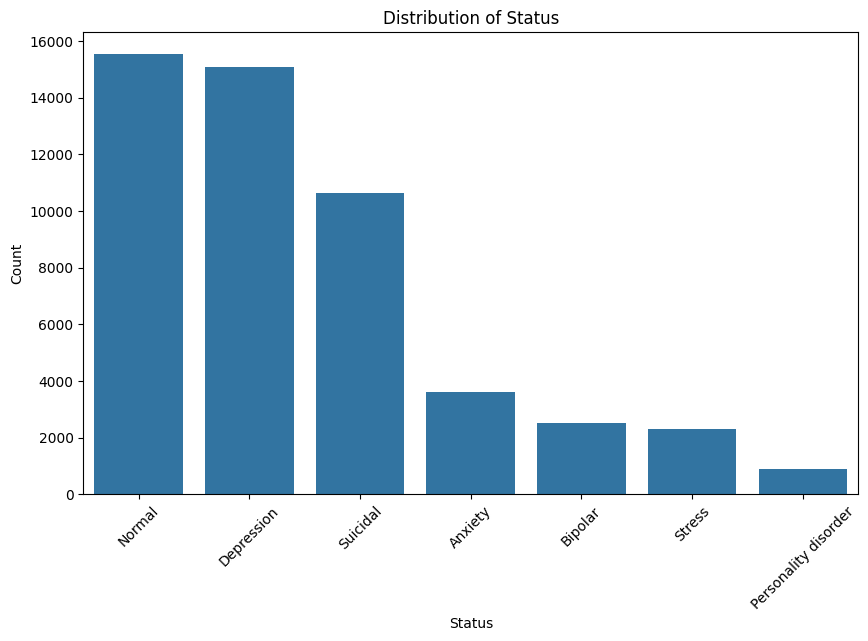

In [148]:
#distribution of different categories in the status column to see the frequency of each status.
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each status
status_counts = df_cleaned['status'].value_counts()

# Plotting the distribution of status
plt.figure(figsize=(10, 6))
sns.barplot(x=status_counts.index, y=status_counts.values)
plt.title("Distribution of Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


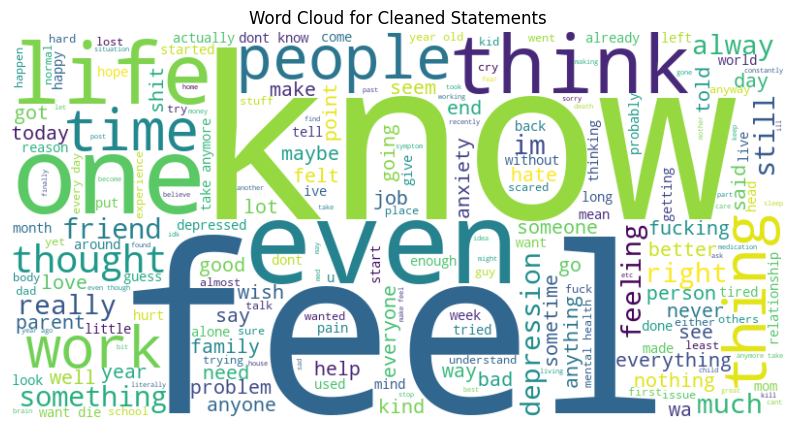

In [149]:
#A word cloud can visually represent the most frequently used words in the cleaned_statement column. It's useful for text analysis
from wordcloud import WordCloud

# Generate the word cloud for cleaned statements
text = ' '.join(df_cleaned['cleaned_statement'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Cleaned Statements')
plt.show()


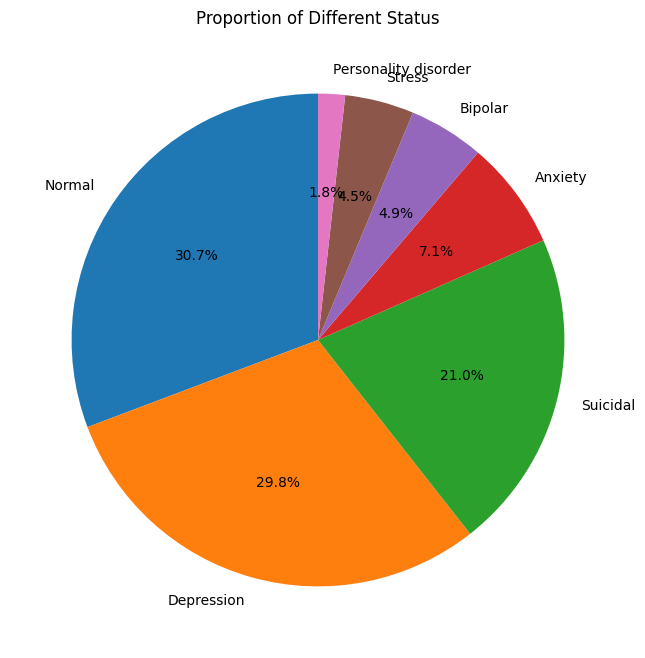

In [150]:
# Pie chart for status distribution
status_counts = df_cleaned['status'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Different Status')
plt.show()


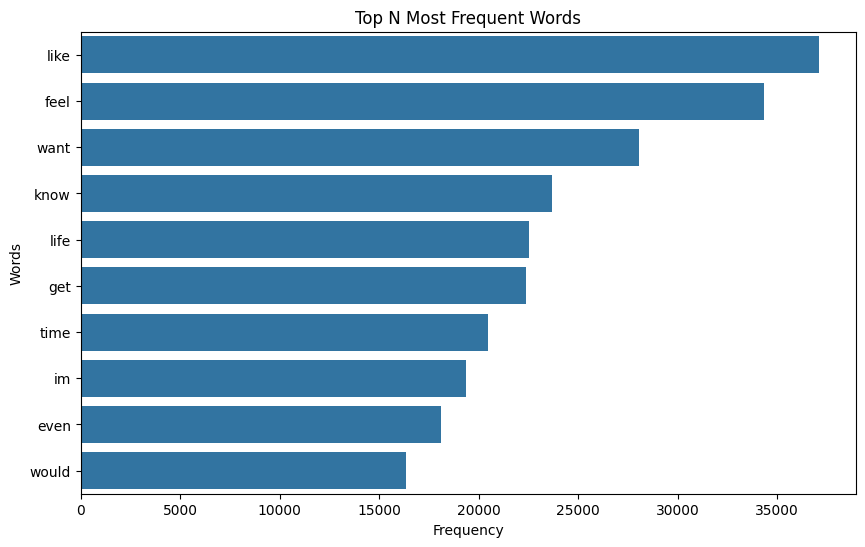

In [151]:
from collections import Counter

# Get word frequency distribution
all_words = ' '.join(df_cleaned['cleaned_statement']).split()
word_freq = Counter(all_words)

# Get top N most common words
top_words = word_freq.most_common(10)

# Plotting the top N frequent words
words, freq = zip(*top_words)
plt.figure(figsize=(10, 6))
sns.barplot(x=freq, y=words)
plt.title("Top N Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()


In [124]:
"""df_sample = df_cleaned.sample(1000)  # Take a random sample of 5000 rows
plt.figure(figsize=(12, 6))
sns.countplot(data=df_sample, x='cleaned_statement', hue='status')
plt.xticks(rotation=90)
plt.title('Frequency of Status by Cleaned Statement')
plt.xlabel('Cleaned Statement')
plt.ylabel('Count')
plt.show()"""


"df_sample = df_cleaned.sample(1000)  # Take a random sample of 5000 rows\nplt.figure(figsize=(12, 6))\nsns.countplot(data=df_sample, x='cleaned_statement', hue='status')\nplt.xticks(rotation=90)\nplt.title('Frequency of Status by Cleaned Statement')\nplt.xlabel('Cleaned Statement')\nplt.ylabel('Count')\nplt.show()"

In [125]:
print(df_cleaned.describe())

       cleaned_statement  status
count              50536   50536
unique             50493       7
top                 name  Normal
freq                   4   15539


In [126]:
#data preprocessing
#1)label encoding

In [152]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.sentiment import SentimentIntensityAnalyzer


sid = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    sentiment_scores = sid.polarity_scores(text)
    return sentiment_scores['compound']  # Compound score (overall sentiment)

# Add sentiment score as a new column
df_cleaned['sentiment_score'] = df_cleaned['cleaned_statement'].apply(get_sentiment_score)

# Check shape before any transformation
print(f"Initial shape of df_cleaned: {df_cleaned.shape}")

# Apply One-Hot Encoding to 'status' column
df_cleaned = pd.get_dummies(df_cleaned, columns=['status'], drop_first=False)
print(f"Shape after one-hot encoding: {df_cleaned.shape}")

print(f"Missing values in cleaned_statement: {df_cleaned['cleaned_statement'].isnull().sum()}")
print(f"Missing values insentiment_score: {df_cleaned['sentiment_score'].isnull().sum()}")
print(f"Missing values in status columns: {df_cleaned[status_columns].isnull().sum()}")

print(f"Duplicate cleaned_statement rows: {df_cleaned.duplicated(subset=['cleaned_statement']).sum()}")
print(f"Shape of df_cleaned before TF-IDF: {df_cleaned.shape}")
print(f"Missing values in cleaned_statement: {df_cleaned['cleaned_statement'].isnull().sum()}")



Initial shape of df_cleaned: (50536, 3)
Shape after one-hot encoding: (50536, 9)
Missing values in cleaned_statement: 0
Missing values insentiment_score: 0
Missing values in status columns: status_Anxiety                 0
status_Bipolar                 0
status_Depression              0
status_Normal                  0
status_Personality disorder    0
status_Stress                  0
status_Suicidal                0
dtype: int64
Duplicate cleaned_statement rows: 43
Shape of df_cleaned before TF-IDF: (50536, 9)
Missing values in cleaned_statement: 0


In [153]:
print(df_cleaned.head())

                                   cleaned_statement  sentiment_score  \
0                                            oh gosh           0.0000   
1  trouble sleeping confused mind restless heart ...          -0.7269   
2  wrong back dear forward doubt stay restless re...          -0.7351   
3  ive shifted focus something else im still worried          -0.2960   
4                im restless restless month boy mean          -0.4939   

   status_Anxiety  status_Bipolar  status_Depression  status_Normal  \
0            True           False              False          False   
1            True           False              False          False   
2            True           False              False          False   
3            True           False              False          False   
4            True           False              False          False   

   status_Personality disorder  status_Stress  status_Suicidal  
0                        False          False            False  
1   

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Assuming df_cleaned is your DataFrame
# and the columns have been set up with the 'status_*' columns as target labels

# Apply TF-IDF to the cleaned_statement
tfidf_vectorizer = TfidfVectorizer(max_features=5000)  # You can adjust max_features as needed
X_tfidf = tfidf_vectorizer.fit_transform(df_cleaned['cleaned_statement'])

# The target variable (y) consists of all the status columns (e.g., status_Normal, status_Anxiety, etc.)
status_columns = [col for col in df_cleaned.columns if col.startswith('status_')]
y = df_cleaned[status_columns]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Multi-output classifier (RandomForestClassifier used here as an example)
clf = MultiOutputClassifier(RandomForestClassifier())

# Train the model
clf.fit(X_train, y_train)

# Predict on the test set
y_pred = clf.predict(X_test)

# Evaluation: You can use classification report to check the performance
print(classification_report(y_test, y_pred, target_names=status_columns))



In [ ]:
# Check for missing values in the dataset
print(df_cleaned.isnull().sum())


In [ ]:
print(df_cleaned.head())